In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.pyplot import imshow
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2

In [2]:
image_height = 64
image_width = 64
image_size = (image_height,image_width)
batch_size = 32

train_datagen = ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_directory(
     r"D:\friday_20_dataset\train",
     target_size=image_size,
     batch_size=batch_size,
     class_mode='binary',
     shuffle=True
)
val_generator = train_datagen.flow_from_directory(
    r"D:\friday_20_dataset\val",
    target_size=image_size,
    batch_size=batch_size,
    class_mode='binary',  
    shuffle=False
)      

Found 5123 images belonging to 2 classes.
Found 718 images belonging to 2 classes.


In [3]:
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    r"D:\friday_20_dataset\test",         
    target_size=image_size,
    batch_size=batch_size,
    class_mode='binary',
    # classes=['benign', 'ddos'],
    shuffle=False
)    

Found 1552 images belonging to 2 classes.


In [5]:
base_model = MobileNetV2(
    input_shape=(64, 64, 3),
    weights='imagenet',
    include_top=False
)
base_model.trainable = False

C:\Users\t0eur\AppData\Local\Temp\ipykernel_22896\4219720246.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


In [6]:
from tensorflow.keras.layers import Conv2D, GlobalAveragePooling2D, Flatten, Dense, Activation, BatchNormalization, Dropout
t_model = keras.models.Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(8, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])
t_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 2, 2, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │        10,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,268,241 (8.65 MB)

 Trainable params: 10,257 (40.07 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [7]:
from keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

t_model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy',metrics=['accuracy', 
             keras.metrics.Precision(),
             keras.metrics.Recall()]
               )



callback = EarlyStopping(
    monitor='val_loss',           
    patience=5,                   
    restore_best_weights=True,    
    verbose=1                     
)

In [8]:
history = t_model.fit(train_generator, validation_data = val_generator, epochs=30, callbacks=[callback],verbose=1)

Epoch 1/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 99s 507ms/step - accuracy: 0.8768 - loss: 0.2608 - precision: 0.9126 - recall: 0.8733 - val_accuracy: 0.9721 - val_loss: 0.0839 - val_precision: 0.9915 - val_recall: 0.9750
Epoch 2/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 32s 200ms/step - accuracy: 0.9348 - loss: 0.1531 - precision: 0.9658 - recall: 0.9213 - val_accuracy: 0.9721 - val_loss: 0.0729 - val_precision: 1.0000 - val_recall: 0.9667
Epoch 3/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 29s 182ms/step - accuracy: 0.9594 - loss: 0.1115 - precision: 0.9854 - recall: 0.9447 - val_accuracy: 0.9847 - val_loss: 0.0390 - val_precision: 1.0000 - val_recall: 0.9817
Epoch 4/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 30s 184ms/step - accuracy: 0.9727 - loss: 0.0951 - precision: 0.9914 - recall: 0.9617 - val_accuracy: 0.9833 - val_loss: 0.0388 - val_precision: 1.0000 - val_recall: 0.9800
Epoch 5/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 32s 198ms/step - accuracy: 0.9682 - loss: 0.0951 - precision: 0.9910 - recall: 0.9543 - val_accuracy: 0.9847

In [9]:
metrics = t_model.evaluate(val_generator)
print("loss:",metrics[0] )
print("Accuracy:", metrics[1])

23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 217ms/step - accuracy: 0.9847 - loss: 0.0264 - precision: 0.9983 - recall: 0.9833        
loss: 0.02643010951578617
Accuracy: 0.984679639339447


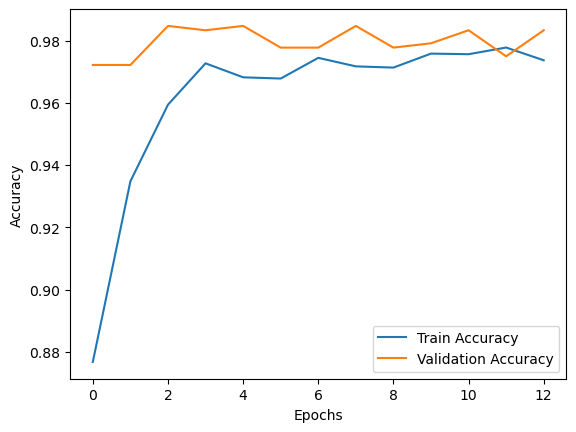

In [10]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['Train Accuracy', 'Validation Accuracy'])
plt.show()

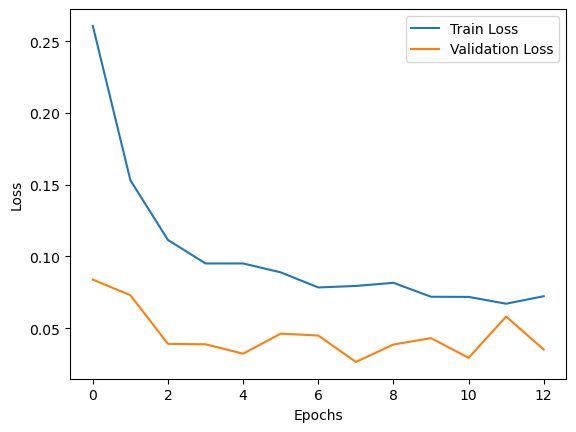

In [11]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['Train Loss', 'Validation Loss'])
plt.show()

49/49 ━━━━━━━━━━━━━━━━━━━━ 15s 300ms/step - accuracy: 0.9839 - loss: 0.0693 - precision: 0.9925 - recall: 0.9888        
Test Accuracy: 0.9839
Test Loss: 0.0693
Test Precision: 0.9925
Test Recall: 0.9888
49/49 ━━━━━━━━━━━━━━━━━━━━ 13s 227ms/step

Confusion Matrix:
[[ 199   10]
 [  15 1328]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.93      0.95      0.94       209
        DDoS       0.99      0.99      0.99      1343

    accuracy                           0.98      1552
   macro avg       0.96      0.97      0.97      1552
weighted avg       0.98      0.98      0.98      1552



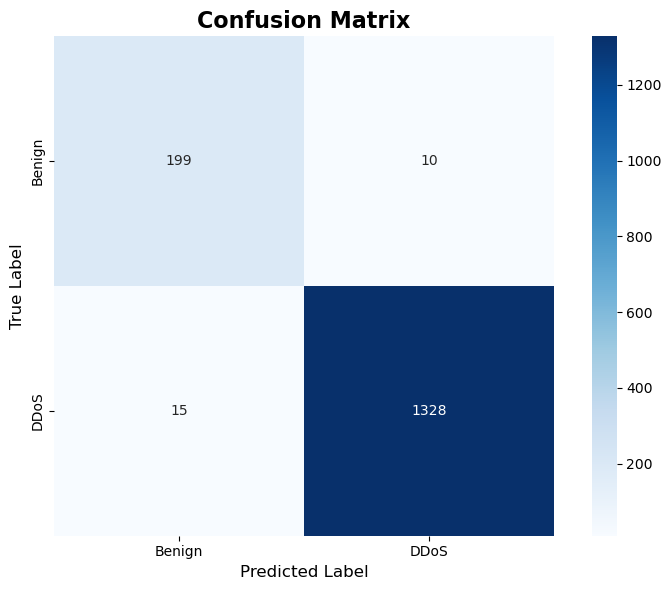

In [12]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

test_generator.reset()
final_results = t_model.evaluate(test_generator, verbose=1)

print(f"Test Accuracy: {final_results[1]:.4f}")
print(f"Test Loss: {final_results[0]:.4f}")
print(f"Test Precision: {final_results[2]:.4f}")
print(f"Test Recall: {final_results[3]:.4f}")

y_pred = t_model.predict(test_generator)
y_pred_classes = (y_pred > 0.5).astype(int).flatten()
y_true = test_generator.classes

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred_classes))
print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=['Benign', 'DDoS']))


cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Benign', 'DDoS'],
            yticklabels=['Benign', 'DDoS'],
            cbar=True, 
            square=True,
            )

plt.title('Confusion Matrix', fontsize=16, weight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()